In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as pyplot

plt.style.use('fivethirtyeight')

In [15]:
def load_stock_data(file):
    df = pd.read_excel(file)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    return df

In [25]:
def prepare_data(df, forecast_days=30):
    df = df[['Close*']].copy()
    df['Prediction'] = df[['Close*']].shift(-forecast_days)
    X = np.array(df.drop('Prediction', axis=1))[:-forecast_days]
    y = np.array(df['Prediction'])[:-forecast_days]

    return X, y, df

In [17]:
def train_and_predict(X, y, df, forecast_days=30):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    mse = mean_squared_error(y_test, prediction)
    r2 = r2_score(y_test, prediction)
    print('Model evaluation')
    print(f'MSE: {mse:.2f}')
    print(f"R2: {r2:.4f}")

    X_future = np.array(df.drop(['Prediction'], axis=1))[-forecast_days:]
    future_prediction = model.predict(X_future)

    return future_prediction, model

In [27]:
def plot_predictions(df, future_days, future_prediction):
    df_future = df.copy()

    last_date = df.index[-1]
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=future_days)

    plt.figure(figsize=(12,6))
    plt.plot(df['Close*'], label="Historical Close Price")
    plt.plot(future_dates, future_prediction, label='Predicted Future Price', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title('Stock Price Prediction')
    plt.legend()
    plt.show()

In [19]:
forecast_days = 30
stock_data = load_stock_data('yahoo_data.xlsx')
print(stock_data)

                Open      High       Low    Close*  Adj Close**     Volume
Date                                                                      
2023-04-28  33797.43  34104.56  33728.40  34098.16     34098.16  354310000
2023-04-27  33381.66  33859.75  33374.65  33826.16     33826.16  343240000
2023-04-26  33596.34  33645.83  33235.85  33301.87     33301.87  321170000
2023-04-25  33828.34  33875.49  33525.39  33530.83     33530.83  297880000
2023-04-24  33805.04  33891.15  33726.09  33875.40     33875.40  252020000
...              ...       ...       ...       ...          ...        ...
2018-05-07  24317.66  24479.45  24263.42  24357.32     24357.32  307670000
2018-05-04  23865.22  24333.35  23778.87  24262.51     24262.51  329480000
2018-05-03  23836.23  23996.15  23531.31  23930.15     23930.15  389240000
2018-05-02  24097.63  24185.52  23886.30  23924.98     23924.98  385350000
2018-05-01  24117.29  24117.29  23808.19  24099.05     24099.05  380070000

[1258 rows x 6 columns]


In [21]:
stock_data.columns

Index(['Open', 'High', 'Low', 'Close*', 'Adj Close**', 'Volume'], dtype='object')

Model evaluation
MSE: 2733954.48
R2: 0.8320


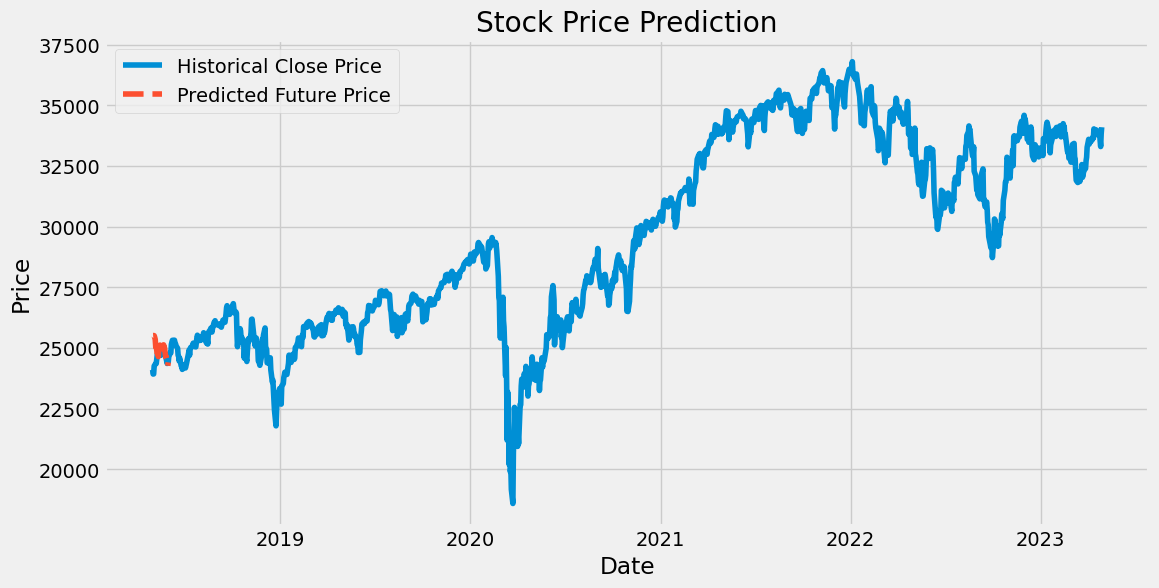

Future Price Predictions:
[25511.73618766 25513.16501385 25507.93804209 25440.00549559
 25354.07697366 25040.8113529  25053.20958523 24891.80648488
 24693.42572444 24921.26019946 24644.2397393  24998.40777057
 25051.46424691 25119.33349098 25071.94710338 25233.71193188
 24964.04359636 24963.03980074 25012.73220529 24956.19409551
 25130.72792769 25069.01710537 24986.1451863  24808.00311582
 24643.11838203 24640.50489615 24554.7662815  24254.206362
 24249.53102566 24406.94607316]


In [28]:
X, y, df = prepare_data(stock_data, forecast_days)
future_prediction, model = train_and_predict(X, y, df, forecast_days)
plot_predictions(df, forecast_days, future_prediction)
print('Future Price Predictions:')
print(future_prediction)